## Customer Segmentation (Manual vs Automatic)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)

Create sample customer data: [Annual Income (k$), Spending Score (1-100)]
Created 90 customer data points

Shape : (90, 2)

First 5 customers:
[[44.96714153 48.61735699]
 [46.47688538 65.23029856]
 [37.65846625 47.65863043]
 [55.79212816 57.67434729]
 [35.30525614 55.42560044]]


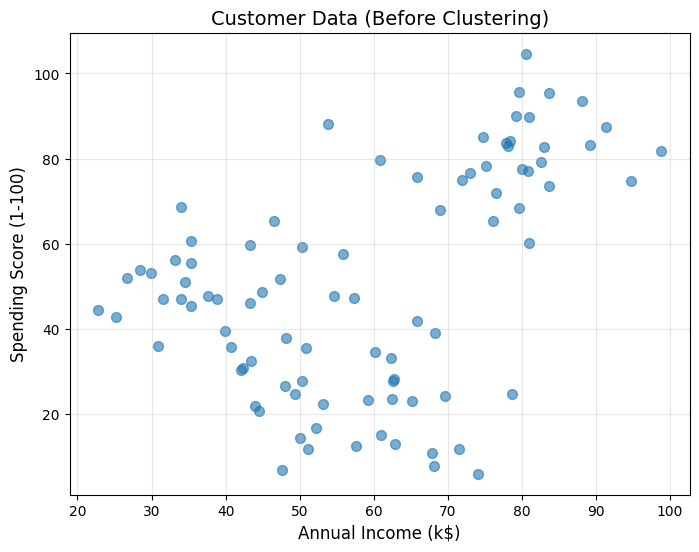


✓ Data created successfully!


In [24]:
print("="*80)
print("Create sample customer data: [Annual Income (k$), Spending Score (1-100)]")
print("="*80)

group1 = np.random.randn(30, 2) * 10 + [40, 50]  # Low income, medium spending
group2 = np.random.randn(30, 2) * 10 + [80, 80]  # High income, high spending
group3 = np.random.randn(30, 2) * 10 + [60, 20]  # Medium income, low spending

X = np.vstack([group1, group2, group3])

print(f"Created {len(X)} customer data points")
print(f"\nShape : {X.shape}")
print(f"\nFirst 5 customers:")
print(X[:5])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=50)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Data (Before Clustering)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Data created successfully!")

<hr>

### Manual Calculation

In [25]:
def Euclidean_Distance(point1, point2):

    distance = np.linalg.norm(point1 - point2)
    return distance


# Find Closest Centroid:
# Assigns Each point to a cluster
def find_closest_centroid(point,centroids):
    
    distances = []
    for centroid in centroids:
        distance = Euclidean_Distance(point,centroid)
        distances.append(distance)

    closest_idx = np.argmin(distances)
    return closest_idx


# Assign each point to cluster
def assign_to_clusters(X,centroids):

    labels = []
    for x in X:
        closest = find_closest_centroid(x,centroids)
        labels.append(closest)

    return np.array(labels)

# Calculate new centroid positions as mean of assigned points
def update_centroids(X,labels,k):

    new_centroids = []

    for cluster_id in range(k):
        cluster_points = X[labels == cluster_id]

        if(len(cluster_points) > 0):
            new_centroid = cluster_points.mean(axis=0)
        else:
            new_centroid = X[np.random.randint(len(X))]    

        new_centroids.append(new_centroid)

    return np.array(new_centroids)

# Putting it all together
def manual_kmeans(X,k=3,max_iters=10,random_state=42):

    np.random.seed(random_state)

    initial_indices = np.random.choice(len(X),k,replace=False)
    centroids = X[initial_indices].copy()

    for iteration in range(max_iters):
        print(f"Iteration {iteration+1}/{max_iters}")

        labels = assign_to_clusters(X,centroids)
        print(f"  Assigned points to clusters: {np.bincount(labels)}")
        
        new_centroids = update_centroids(X, labels, k)
        
        centroid_shift = np.sum(np.abs(new_centroids - centroids))
        print(f"  Centroid shift: {centroid_shift:.4f}")
        
        if centroid_shift < 0.001:
            print(f"\n✓ Converged after {iteration + 1} iterations!")
            centroids = new_centroids
            break
        
        centroids = new_centroids
        print()
    
    labels = assign_to_clusters(X, centroids)
    
    return centroids, labels


In [26]:
print("="*60)
print("RUNNING MANUAL K-MEANS ALGORITHM")
print("="*60 + "\n")

centroids,labels = manual_kmeans(X,k=3,max_iters=10)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print("\nFinal centroids:")
for i, c in enumerate(centroids):
    print(f"  Cluster {i}: Income=${c[0]:.2f}k, Spending={c[1]:.2f}")

print(f"\nFinal cluster distribution:")
for i in range(3):
    count = np.sum(labels == i)
    print(f"  Cluster {i}: {count} customers")

print("\n✓ K-Means algorithm complete!")

RUNNING MANUAL K-MEANS ALGORITHM

Iteration 1/10
  Assigned points to clusters: [26 55  9]
  Centroid shift: 54.7774

Iteration 2/10
  Assigned points to clusters: [25 53 12]
  Centroid shift: 13.0928

Iteration 3/10
  Assigned points to clusters: [26 49 15]
  Centroid shift: 14.5180

Iteration 4/10
  Assigned points to clusters: [29 39 22]
  Centroid shift: 27.2740

Iteration 5/10
  Assigned points to clusters: [30 34 26]
  Centroid shift: 9.2165

Iteration 6/10
  Assigned points to clusters: [30 32 28]
  Centroid shift: 3.0829

Iteration 7/10
  Assigned points to clusters: [30 32 28]
  Centroid shift: 0.0000

✓ Converged after 7 iterations!

FINAL RESULTS

Final centroids:
  Cluster 0: Income=$78.94k, Spending=80.99
  Cluster 1: Income=$57.79k, Spending=22.59
  Cluster 2: Income=$38.79k, Spending=50.14

Final cluster distribution:
  Cluster 0: 30 customers
  Cluster 1: 32 customers
  Cluster 2: 28 customers

✓ K-Means algorithm complete!


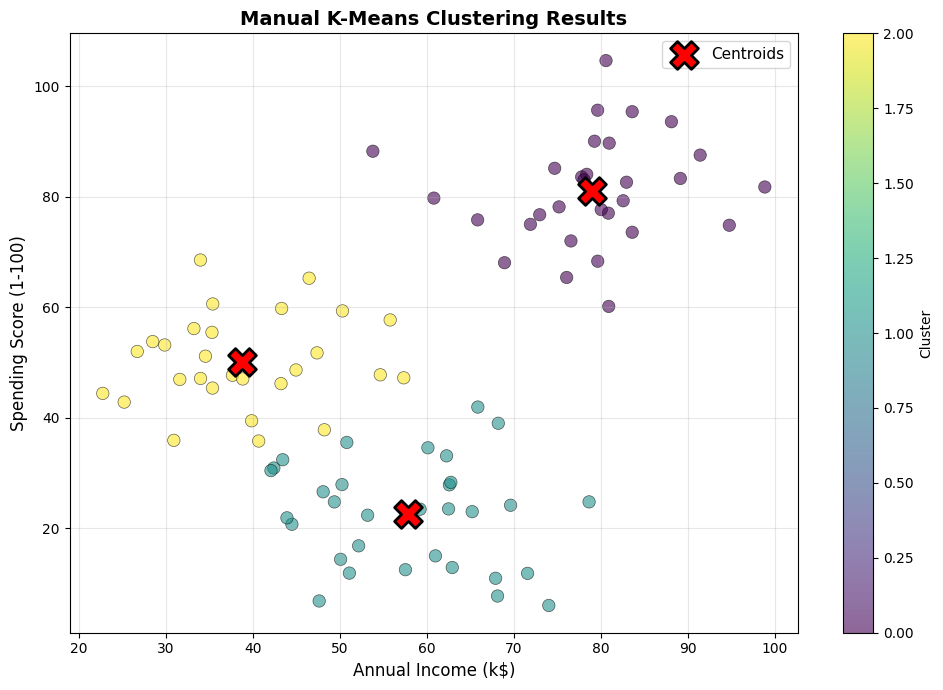

CLUSTER ANALYSIS

Cluster 0:
  Number of customers: 30
  Centroid: Income=$78.94k, Spending=80.99
  Average Income: $78.94k
  Average Spending: 80.99
  Type: 💎 Premium (High income, High spending)

Cluster 1:
  Number of customers: 32
  Centroid: Income=$57.79k, Spending=22.59
  Average Income: $57.79k
  Average Spending: 22.59
  Type: 📊 Mixed segment

Cluster 2:
  Number of customers: 28
  Centroid: Income=$38.79k, Spending=50.14
  Average Income: $38.79k
  Average Spending: 50.14
  Type: 🎯 Budget-conscious (Low income, Medium spending)


In [28]:
def plot_clusters(X, labels, centroids, title="K-Means Clustering"):
    
    plt.figure(figsize=(10, 7))
    
    # Plot points colored by cluster
    scatter = plt.scatter(X[:, 0], X[:, 1], 
                         c=labels, 
                         cmap='viridis', 
                         alpha=0.6, 
                         s=80,
                         edgecolors='black',
                         linewidth=0.5)
    
    plt.scatter(centroids[:, 0], centroids[:, 1], 
               c='red', 
               marker='X', 
               s=400, 
               edgecolors='black', 
               linewidth=2,
               label='Centroids',
               zorder=5)
    
    plt.xlabel('Annual Income (k$)', fontsize=12)
    plt.ylabel('Spending Score (1-100)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Cluster')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

plot_clusters(X, labels, centroids, 
                 title="Manual K-Means Clustering Results")
    

print("="*60)
print("CLUSTER ANALYSIS")
print("="*60)
    
for cluster_id in range(len(centroids)):
    cluster_points = X[labels == cluster_id]
        
    print(f"\nCluster {cluster_id}:")
    print(f"  Number of customers: {len(cluster_points)}")
    print(f"  Centroid: Income=${centroids[cluster_id][0]:.2f}k, "
    f"Spending={centroids[cluster_id][1]:.2f}")
    print(f"  Average Income: ${cluster_points[:, 0].mean():.2f}k")
    print(f"  Average Spending: {cluster_points[:, 1].mean():.2f}")
        
    # Interpret the cluster
    avg_income = cluster_points[:, 0].mean()
    avg_spending = cluster_points[:, 1].mean()
        
    if avg_income > 70 and avg_spending > 60:
        segment = "💎 Premium (High income, High spending)"
    elif avg_income < 50 and avg_spending > 40:
        segment = "🎯 Budget-conscious (Low income, Medium spending)"
    elif avg_income > 60 and avg_spending < 40:
        segment = "💼 Selective (Medium income, Low spending)"
    else:
        segment = "📊 Mixed segment"
        
    print(f"  Type: {segment}")


<hr> 

### Comapring with Sklearn implementation

COMPARING MANUAL vs SKLEARN K-MEANS
Manual implementation clustered 90 points
Manual centroids:
[[78.94078991 80.98554155]
 [57.7912549  22.5893065 ]
 [38.79154362 50.14337699]]

Running sklearn K-Means
Sklearn centroids:
[[57.7912549  22.5893065 ]
 [38.79154362 50.14337699]
 [78.94078991 80.98554155]]



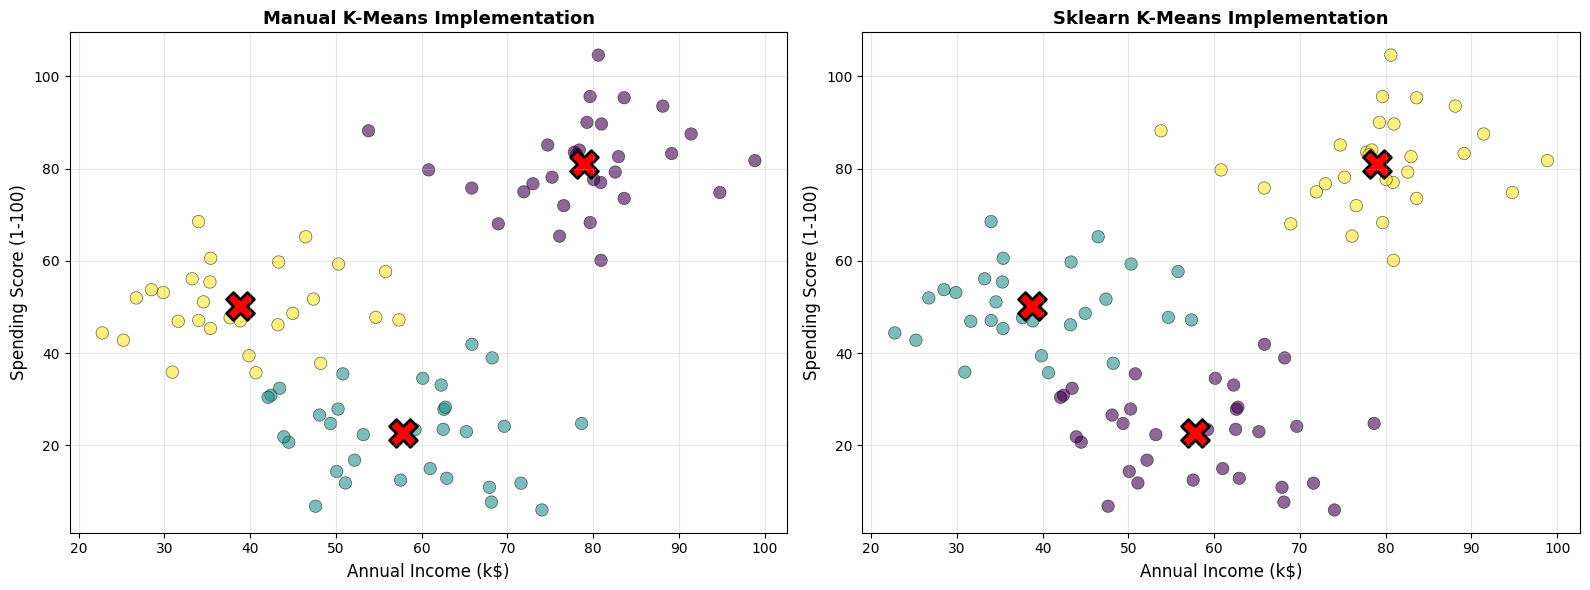

In [30]:
print("="*60)
print("COMPARING MANUAL vs SKLEARN K-MEANS")
print("="*60)

print(f"Manual implementation clustered {len(X)} points")
print(f"Manual centroids:\n{centroids}\n")

print("Running sklearn K-Means")
sklearn_kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
sklearn_kmeans.fit(X)

sklearn_labels = sklearn_kmeans.labels_
sklearn_centroids = sklearn_kmeans.cluster_centers_

print(f"Sklearn centroids:\n{sklearn_centroids}\n")


# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Manual implementation
axes[0].scatter(X[:, 0], X[:, 1], c=labels, 
               cmap='viridis', alpha=0.6, s=80, 
               edgecolors='black', linewidth=0.5)
axes[0].scatter(centroids[:, 0], centroids[:, 1], 
               c='red', marker='X', s=400, 
               edgecolors='black', linewidth=2)
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title('Manual K-Means Implementation', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Sklearn implementation
axes[1].scatter(X[:, 0], X[:, 1], c=sklearn_labels, 
               cmap='viridis', alpha=0.6, s=80, 
               edgecolors='black', linewidth=0.5)
axes[1].scatter(sklearn_centroids[:, 0], sklearn_centroids[:, 1], 
               c='red', marker='X', s=400, 
               edgecolors='black', linewidth=2)
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Sklearn K-Means Implementation', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()